In [70]:
import numpy as np 
import pickle 
import pandas as pd 
from sklearn.metrics import confusion_matrix
import re
%matplotlib inline 
import matplotlib.pyplot as plt 
import seaborn as sns
import yaml 
from pathlib import Path
import matplotlib
# matplotlib.rcParams.update({'font.size': 26})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import sys
sys.path.append('../')

import figure_utils
from importlib import reload
reload(figure_utils)
from figure_utils import (
    format_model_str,
    format_model_str_word_task,
    normalize_model_list,
    normalize_model_name,
    normalize_palette_dict,
    marker_palette_for_hue,
        get_standard_base_colors,

    build_model_palette,
)

## Get ESC 50 results for each model

In [ ]:
path_to_esc_results = Path("esc_analysis")

all_model_results = list(path_to_esc_results.rglob("*barlow*kell2018*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("audioset_*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("resnet18_barlow*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("resnet50_barlow*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("kell2018_barlow*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("kell2018*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("word_kell2018*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("config_linear*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("byola*/saved_vars*.pickle"))
# all_model_results

In [18]:


test_layers = [
                'preproc',
                'batchnorm0',
                'conv0',
                'relu0',
                'maxpool0',
                'batchnorm1',
                'conv1',
                'relu1',
                'maxpool1',
                'batchnorm2',
                'conv2',
                'relu2',
                'conv3',
                'relu3',
                'conv4',
                'relu4',
                'avgpool',
                'fullyconnected',
                'relufc',
                'dropout',
                ]
                
resnet18_layer_order = [
                'preproc',
                'conv1',
                'bn1',
                'relu1',
                'maxpool1',
                'layer1',
                'layer2',
                'layer3',
                'layer4',
                'avgpool',
            ]            
layer_order_dict = {l:i for i,l in enumerate(test_layers)}
df_list = []

for i, results_path in enumerate(all_model_results):
    path_str = str(results_path)

    if 'kell2018' in path_str and not results_path.parent.stem.startswith('kell2018'):
        if 'eq_lmbda' in path_str:
            # if 'fixed_loss' not in path_str:
            continue 
    if "resnet18" in path_str:
        if "barlow" in path_str:
            if "invar_augment" not in path_str and "audioset" not in path_str:
                continue  
    if 'projects' in str(results_path):
        continue 
    results = pd.read_pickle(results_path)
    overall_acc = results['overall_acc']

    model_name, arch_class, test_layer, eq_lmbda = format_model_str(results_path)
    
    data = dict(model_name=model_name, arch_class=arch_class, test_layer=test_layer, eq_lmbda=eq_lmbda, overall_acc=overall_acc)
    if i == 0:
        category_list = np.array(list(results['target_to_category'].values()))

    df_list.append(data)

esc_50_df = pd.DataFrame.from_records(df_list)
esc_50_df['test_layer'] = esc_50_df['test_layer'].astype('str')
esc_50_df['model_name'] = esc_50_df['model_name'].apply(normalize_model_name)

esc_50_df = esc_50_df.loc[esc_50_df['test_layer'].map({k: i for i, k in enumerate(test_layers)}) \
                .sort_values().index]

In [19]:


esc_50_df.model_name.unique()

array(['resnet18 ssl λ=0.0', 'CochCNN9 supervised multi-task',
       'resnet18 ssl λ=1.0', 'CochCNN9 ssl λ=0.1',
       'CochCNN9 ssl dual λ=0.0', 'CochCNN9 ssl dual λ=0.5',
       'CochCNN9 ssl λ=0.3', 'CochCNN9 ssl λ=0.2', 'CochCNN9 ssl λ=0.5',
       'CochCNN9 ssl λ=0.8', 'CochCNN9 ssl λ=0.4',
       'CochCNN9 supervised audioset', 'CochCNN9 ssl λ=0.0',
       'CochCNN9 supervised word', 'resnet18 ssl λ=0.4',
       'resnet18 ssl λ=0.1', 'resnet18 ssl λ=0.2', 'resnet18 ssl λ=0.3',
       'resnet18 ssl λ=0.01', 'resnet18 ssl λ=0.5',
       'CochCNN9 scaled ssl λ=0.5',
       'CochCNN9 ssl dual λ=0.0 unpaired augs',
       'CochCNN9 scaled ssl λ=0.0', 'CochCNN9 ssl dual λ=0.01',
       'CochCNN9 ssl λ=1.0', 'CochCNN9 ssl dual λ=0.1',
       'CochCNN9 scaled supervised', 'resnet18 scaled ssl λ=0.0',
       'resnet18 scaled ssl λ=0.5', 'resnet50 ssl λ=0.5',
       'resnet50 scaled ssl λ=0.5', 'resnet18 supervised audioset',
       'resnet50 supervised audioset', 'byol-a λ=0.0', 'byol-a

## Get word task results 

In [49]:
path_to_word_results = Path("eval_jsin_results")
kell2018_word_results = list(path_to_word_results.rglob("*kell2018*.pkl"))
kell2018_word_results = [path for path in kell2018_word_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands']])]

# kell2018_word_results = list(path_to_word_results.rglob("*kell2018*.pkl"))
# kell2018_word_results = [path for path in kell2018_word_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands']])]

resnet18_word_results = list(path_to_word_results.rglob("*resnet18*.pkl"))
resnet18_word_results = [path for path in resnet18_word_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands']])]

resnet50_word_results = list(path_to_word_results.rglob("resnet50*.pkl"))
resnet50_word_results = [path for path in resnet50_word_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands']])]

byola_results =  list(path_to_word_results.rglob("config_linear*.pkl"))
byola_results = [path for path in byola_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands', '0.01']])]

byola_results_new =  list(path_to_word_results.rglob("byola*.pkl"))
byola_results += [path for path in byola_results_new if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands', '0.01']])]

all_word_task_results = kell2018_word_results + resnet18_word_results + resnet50_word_results + byola_results

df_list = []

for i, results_path in enumerate(all_word_task_results):
    path_str = str(results_path)
    # if results_path.name.startswith('audioset'):
    #     print(path_str)

    if 'kell2018' in path_str and not results_path.name.startswith('kell2018'):
        if 'eq_lmbda' in path_str:

            # if 'fixed_loss' not in path_str:
            continue 
    if 'kell2018' in path_str and not 'w_dropout_center_eval_words' in path_str:

        continue
        
    # if not any([layer in str(results_path) for layer in test_layers + resnet18_layer_order]):
        # continue 
    if "resnet18" in path_str:
        if "barlow" in path_str:
            if "invar_augment" not in path_str and "audioset" not in path_str:
                continue
    results = pd.read_pickle(results_path)
    # break 

    model_name, arch_class, test_layer, eq_lmbda = format_model_str_word_task(results_path)
    
    data = dict(model_name=model_name, arch_class=arch_class, test_layer=test_layer, eq_lmbda=eq_lmbda)
    data = {**data, **results}


    df_list.append(data)

word_df = pd.DataFrame.from_records(df_list)
word_df['test_layer'] = word_df['test_layer'].astype('str')
word_df['model_name'] = word_df['model_name'].apply(normalize_model_name)
word_df['task'] = '800-word classification'

In [90]:
word_df.loc[word_df.model_name == "resnet18 supervised word", 'test_layer'] = 'avgpool'

In [50]:
word_df.model_name.unique()

array(['CochCNN9 ssl λ=0.5', 'CochCNN9 ssl dual λ=0.0 unpaired augs',
       'CochCNN9 ssl dual λ=0.01', 'CochCNN9 supervised word',
       'CochCNN9 ssl λ=0.3', 'CochCNN9 ssl λ=0.1', 'CochCNN9 ssl λ=0.4',
       'CochCNN9 ssl λ=0.2', 'CochCNN9 supervised multi-task',
       'CochCNN9 scaled ssl λ=0.0', 'CochCNN9 scaled ssl λ=0.5',
       'CochCNN9 supervised audioset', 'CochCNN9 ssl λ=0.0',
       'CochCNN9 ssl dual λ=0.5', 'CochCNN9 ssl dual λ=0.1',
       'CochCNN9 scaled supervised', 'CochCNN9 ssl λ=1.0',
       'CochCNN9 ssl dual λ=0.0', 'resnet18 ssl λ=0.5',
       'resnet18 ssl λ=0.1', 'resnet18 ssl λ=0.3',
       'resnet18 scaled ssl λ=0.5', 'resnet18 supervised multi-task',
       'resnet18 scaled ssl λ=0.0', 'resnet18 ssl λ=0.0',
       'resnet18 ssl λ=0.4', 'resnet18 supervised word',
       'resnet18 ssl λ=0.2', 'resnet18 supervised', 'resnet18 ssl λ=0.01',
       'resnet18 ssl λ=1.0', 'resnet50 scaled ssl λ=0.5', 'byol-a',
       'byol-a λ=0.0'], dtype=object)

In [91]:
df = pd.concat([word_df, esc_50_df], axis=0, ignore_index=True)
df.head()

,model_name,arch_class,test_layer,eq_lmbda,word_top1_mean,word_top1_sem,speaker_top1_mean,speaker_top1_sem,word_top5_mean,word_top5_sem,speaker_top5_mean,speaker_top5_sem,word_task_mean,speaker_task_mean,noise_task_mean,word_task_top5,speaker_task_top5,task,overall_acc
0,CochCNN9 ssl λ=0.5,kell2018,relu0,0.5,0.184229,0.001017,0.983177,0.000388,0.827061,0.006277,0.995555,2.107547e-04,NaN,NaN,NaN,NaN,NaN,800-word classification,NaN
1,CochCNN9 ssl dual λ=0.0 unpaired augs,kell2018,relu4,0.0,0.756403,0.001014,0.999490,0.000049,0.989996,0.000270,1.000000,2.942227e-10,NaN,NaN,NaN,NaN,NaN,800-word classification,NaN
2,CochCNN9 ssl dual λ=0.01,kell2018,relu4,0.01,0.734701,0.001058,0.999429,0.000051,0.988358,0.000291,1.000000,2.942227e-10,NaN,NaN,NaN,NaN,NaN,800-word classification,NaN
3,CochCNN9 supervised word,kell2018,relu1,,0.726751,0.001035,0.998746,0.000078,0.972820,0.000693,0.999921,1.837652e-05,NaN,NaN,NaN,NaN,NaN,800-word classification,NaN
4,CochCNN9 ssl λ=0.3,kell2018,relu2,0.3,0.811457,0.000937,0.999703,0.000035,0.993793,0.000189,0.999996,4.343880e-06,NaN,NaN,NaN,NaN,NaN,800-word classification,NaN


# Plot ESC 50 results

In [57]:
esc_50_to_plot = df[(df.arch_class == 'kell2018') & (~df.overall_acc.isna()) & (df.test_layer.str.contains('relu'))]
# esc_50_to_plot[esc_50_to_plot.eq_lmbda == ' 5e-01'].groupby(['test_layer', 'model_name']).overall_acc.max()

### Make main figure plot with supervised models as reflines

In [174]:
hue_order = [
    # Supervised
    'CochCNN9 supervised multi-task',
    'CochCNN9 supervised word',
    'CochCNN9 supervised audioset',
    'CochCNN9 scaled supervised',
    # SSL / Equivariant
    'CochCNN9 ssl λ=0.0',
    'CochCNN9 ssl λ=0.1',
    'CochCNN9 ssl λ=0.2',
    'CochCNN9 ssl λ=0.3',
    'CochCNN9 ssl λ=0.4',
    'CochCNN9 ssl λ=0.5',
    'CochCNN9 scaled ssl λ=0.0',
    'CochCNN9 scaled ssl λ=0.5',
    # SSL / Dual
    'CochCNN9 ssl dual λ=0.0',
    'CochCNN9 ssl dual λ=0.0 unpaired augs',
    'CochCNN9 ssl dual λ=0.01',
    'CochCNN9 ssl dual λ=0.1',
    'CochCNN9 ssl dual λ=0.5',
    # Resnets 50
    'resnet50 ssl λ=0.5',
    'resnet50 scaled ssl λ=0.5',
    # Resnet 18
    'resnet18 scaled ssl λ=0.0',
    'resnet18 scaled ssl λ=0.5',
]

hue_order = normalize_model_list(hue_order)
marker_palette = marker_palette_for_hue(hue_order)

# set palette via shared utils
base_colors = {
    'CochCNN9 supervised word': 'blue',
    'CochCNN9 supervised audioset': 'orange',
    'CochCNN9 scaled supervised': 'red',
    'CochCNN9 supervised multi-task': 'grey',
}
base_colors = normalize_palette_dict(base_colors)

hue_dict = build_model_palette(hue_order, base_colors)

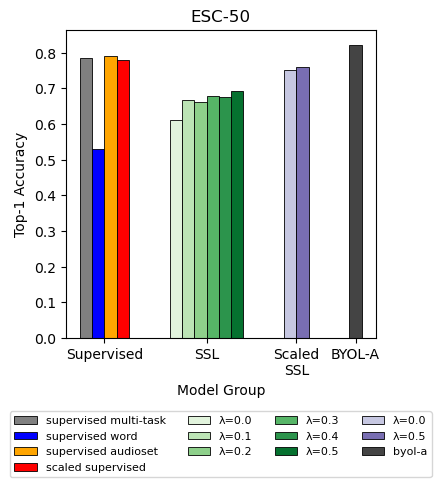

In [175]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import re


# Focus on relu layers only (as before)
esc_50_to_plot = df[~df.overall_acc.isna() & ((df.test_layer.str.contains('relu4')) | ((df.model_name == 'byol-a') & (df.test_layer.str.contains('final'))))]

# Model groups
supervised_names = [
    'CochCNN9 supervised multi-task',
    'CochCNN9 supervised word',
    'CochCNN9 supervised audioset',
    'CochCNN9 scaled supervised',
]
ssl_names = [name for name in hue_order
             if name.startswith('CochCNN9 ssl ') and 'dual' not in name and 'scaled' not in name]
scaled_ssl_names = [name for name in hue_order if name.startswith('CochCNN9 scaled ssl ')]
byol_names = ['byol-a']

supervised_names = normalize_model_list(supervised_names)
ssl_names = normalize_model_list(ssl_names)
scaled_ssl_names = normalize_model_list(scaled_ssl_names)
byol_names = normalize_model_list(byol_names)


def strip_cochdnn9(name):
    return name.replace('CochCNN9 ', '')


def lambda_label(name):
    match = re.search(r'(?:λ|lambda)\s*=\s*([0-9.]+)', name, re.IGNORECASE)
    return f"λ={match.group(1)}" if match else strip_cochdnn9(name)


def model_label(name):
    if name.startswith('CochCNN9 ssl ') or name.startswith('CochCNN9 scaled ssl '):
        return lambda_label(name)
    return strip_cochdnn9(name)


# Prepare grouped data
plot_groups = [
    ('Supervised', supervised_names),
    ('SSL', ssl_names),
    ('Scaled\nSSL', scaled_ssl_names),
    ('BYOL-A', byol_names),
]

means = (esc_50_to_plot.groupby('model_name', as_index=True)['overall_acc']
         .mean())

fig, ax = plt.subplots(figsize=(4, 4))
bar_width = 0.18
group_gap = 0.6

xticks = []
xticklabels = []
legend_handles = []
legend_labels = []

x_cursor = 0.0
for group_name, models in plot_groups:
    models = [m for m in models if m in means.index]
    if len(models) == 0:
        continue

    group_start = x_cursor
    for i, model in enumerate(models):
        x = x_cursor + i * bar_width
        color = hue_dict.get(model, '#444444')
        label = model_label(model)
        bar = ax.bar(x, means.loc[model], width=bar_width, color=color, edgecolor='black', linewidth=0.6, label=label)
        # if label not in legend_labels:
        legend_handles.append(bar[0])
        legend_labels.append(label)

    group_center = group_start + (len(models) - 1) * bar_width / 2
    xticks.append(group_center)
    xticklabels.append(group_name)
    x_cursor += len(models) * bar_width + group_gap

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_ylabel('Top-1 Accuracy')
ax.set_xlabel('Model Group')
ax.set_title('ESC-50')

# Ensure scaled SSL palette entries appear in legend, even if missing from data
for model in scaled_ssl_names:
    label = model_label(model)
    if label not in legend_labels:
        color = hue_dict.get(model, '#444444')
        legend_handles.append(Patch(facecolor=color, edgecolor='black'))
        legend_labels.append(label)

if legend_handles:
    ax.legend(
        legend_handles,
        legend_labels,
        frameon=True,
        fontsize=8,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.22),
        ncol=4,
    )

# ax.grid(axis='y', alpha=0.3, zorder=-1)
# ax.set_xlim(-1, 1.0)

# plt.subplots_adjust(bottom=0.3)
# plt.tight_layout()
# plt.show()

## Plot WSN word eval

(0.0, 1.0)

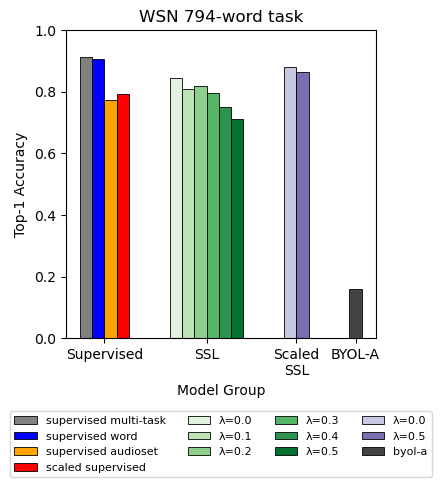

In [184]:
# Focus on relu layers only (as before)
word_to_plot = df[~df.word_top1_mean.isna() & ((df.test_layer.str.contains('relu4')) | ((df.model_name == 'byol-a') & (df.test_layer.str.contains('final'))))]

# Model groups
supervised_names = [
    'CochCNN9 supervised multi-task',
    'CochCNN9 supervised word',
    'CochCNN9 supervised audioset',
    'CochCNN9 scaled supervised',
]
ssl_names = [name for name in hue_order
             if name.startswith('CochCNN9 ssl ') and 'dual' not in name and 'scaled' not in name]
scaled_ssl_names = [name for name in hue_order if name.startswith('CochCNN9 scaled ssl ')]
byol_names = ['byol-a']

supervised_names = normalize_model_list(supervised_names)
ssl_names = normalize_model_list(ssl_names)
scaled_ssl_names = normalize_model_list(scaled_ssl_names)
byol_names = normalize_model_list(byol_names)


def strip_cochdnn9(name):
    return name.replace('CochCNN9 ', '')


def lambda_label(name):
    match = re.search(r'(?:λ|lambda)\s*=\s*([0-9.]+)', name, re.IGNORECASE)
    return f"λ={match.group(1)}" if match else strip_cochdnn9(name)


def model_label(name):
    if name.startswith('CochCNN9 ssl ') or name.startswith('CochCNN9 scaled ssl '):
        return lambda_label(name)
    return strip_cochdnn9(name)


# Prepare grouped data
plot_groups = [
    ('Supervised', supervised_names),
    ('SSL', ssl_names),
    ('Scaled\nSSL', scaled_ssl_names),
    ('BYOL-A', byol_names),
]

means = (word_to_plot.groupby('model_name', as_index=True)['word_top1_mean']
         .mean())

fig, ax = plt.subplots(figsize=(4, 4))
bar_width = 0.18
group_gap = 0.6

xticks = []
xticklabels = []
legend_handles = []
legend_labels = []

x_cursor = 0.0
for group_name, models in plot_groups:
    models = [m for m in models if m in means.index]
    if len(models) == 0:
        continue

    group_start = x_cursor
    for i, model in enumerate(models):
        x = x_cursor + i * bar_width
        color = hue_dict.get(model, '#444444')
        label = model_label(model)
        bar = ax.bar(x, means.loc[model], width=bar_width, color=color, edgecolor='black', linewidth=0.6, label=label)
        # if label not in legend_labels:
        legend_handles.append(bar[0])
        legend_labels.append(label)

    group_center = group_start + (len(models) - 1) * bar_width / 2
    xticks.append(group_center)
    xticklabels.append(group_name)
    x_cursor += len(models) * bar_width + group_gap

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_ylabel('Top-1 Accuracy')
ax.set_xlabel('Model Group')
ax.set_title('WSN 794-word task')

# Ensure scaled SSL palette entries appear in legend, even if missing from data
for model in scaled_ssl_names:
    label = model_label(model)
    if label not in legend_labels:
        color = hue_dict.get(model, '#444444')
        legend_handles.append(Patch(facecolor=color, edgecolor='black'))
        legend_labels.append(label)

if legend_handles:
    ax.legend(
        legend_handles,
        legend_labels,
        frameon=True,
        fontsize=8,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.22),
        ncol=4,
    )

# ax.grid(axis='y', alpha=0.3, zorder=-1)
ax.set_ylim(0, 1.0)

# plt.subplots_adjust(bottom=0.3)
# plt.tight_layout()
# plt.show()

#### Other plots

/tmp/ipykernel_115749/623209481.py:119: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(labels=hue_order, rotation=90)  # ha='right', rotation_mode='anchor'


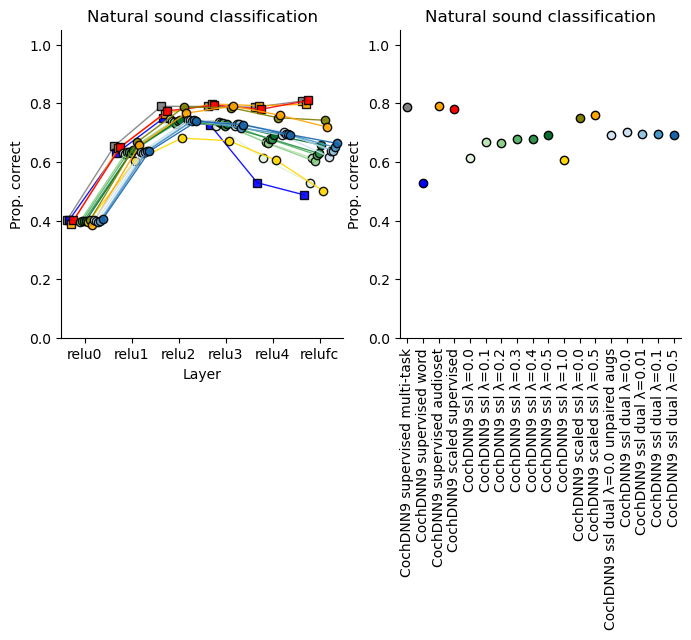

In [133]:
hue_order = [
    # Supervised
    'kell2018 supervised multi-task',
    'kell2018 supervised word',
    'kell2018 supervised jsin audioset',
    'kell2018 supervised unbalanced audioset',

    # SSL / Invariant
    'kell2018 ssl word',

    # SSL / Equivariant
    'kell2018 ssl λ=0.1',
    'kell2018 ssl λ=0.2',
    'kell2018 ssl λ=0.3',
    'kell2018 ssl λ=0.4',
    'kell2018 ssl λ=0.5',
    'kell2018 ssl audioset',
    'kell2018 ssl unbalanced audioset λ=0.0',  
    'kell2018 ssl unbalanced audioset λ=0.5',  

    # SSL / Dual
    'kell2018 ssl dual λ=0.0 unpaired augs',
    'kell2018 ssl dual λ=0.0',
    'kell2018 ssl dual λ=0.01',
    'kell2018 ssl dual λ=0.1',
    'kell2018 ssl dual λ=0.5',
]

hue_order = normalize_model_list(hue_order)
marker_palette = marker_palette_for_hue(hue_order)



# set palette 
hue_dict = {}
hue_dict['kell2018 supervised word'] = 'blue'
hue_dict['kell2018 supervised jsin audioset'] = 'orange' 
hue_dict['kell2018 supervised unbalanced audioset'] = 'red'
hue_dict['kell2018 ssl unbalanced audioset λ=0.0'] = 'olive' 
hue_dict['kell2018 ssl unbalanced audioset λ=0.5'] = 'orange' 
hue_dict['kell2018 ssl audioset'] = 'gold' 
hue_dict['kell2018 supervised multi-task'] = 'grey'
# hue_dict['kell2018 ssl word'] = 'magenta'
# hue_dict['kell2018 dual equivariant 5e-01'] = 'olive'

layer_order = [
    'relu0', 'relu1', 'relu2', 'relu3', 'relu4', 'relufc'
]

eq_model_list = hue_order[4:10]
equi_palette = sns.color_palette("Greens", n_colors=len(eq_model_list)) 
equi_color_dict = dict(zip(eq_model_list, equi_palette))

dual_models = [
    'kell2018 ssl dual λ=0.0',
    'kell2018 ssl dual λ=0.01',
    'kell2018 ssl dual λ=0.1',
    'kell2018 ssl dual λ=0.5',
]

dual_palette = sns.color_palette("Blues", n_colors=len(dual_models)) 
dual_color_dict = dict(zip(dual_models, dual_palette))

unpaired_base = dual_color_dict['kell2018 ssl dual λ=0.0']
hue_dict['kell2018 ssl dual λ=0.0 unpaired augs'] = sns.dark_palette(unpaired_base, n_colors=3)[-1]

hue_dict = {**hue_dict, **equi_color_dict, **dual_color_dict}
hue_dict = normalize_palette_dict(hue_dict)

esc_50_to_plot = df[(df.arch_class == 'kell2018') & (~df.overall_acc.isna()) & (df.test_layer.str.contains('relu'))]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

g = sns.pointplot(
    data=esc_50_to_plot, 
    order=layer_order,
    hue='model_name', y='overall_acc',
    x="test_layer",
    palette=hue_dict,
    hue_order=hue_order,
    alpha=0.9,
    dodge=0.75,
    ax=axes[0],
    legend=False,
    markers=marker_palette,
    # ls='',
    mec='k',
    mew=1,
    lw=1, ms=6
    #  height=4, 
)
g.set(ylim=(0, 1.05), title="Natural sound classification", ylabel='Prop. correct', xlabel='Layer')

test_layers = ['relu4', 'final', 'avgpool']

to_plot = esc_50_to_plot[(esc_50_to_plot.model_name.isin(hue_order)) & esc_50_to_plot.test_layer.isin(test_layers)]
to_plot = to_plot[~((to_plot.model_name.str.contains('kell')) & to_plot.test_layer.str.contains('avgpool'))]

# models_for_esc = ['kell2018 supervised word', 'kell2018 supervised multi-task', 'byol-a ']
# esc_50_to_plot = esc_50_to_plot[esc_50_to_plot.model_name.str.contains('kell2018|byola')]

g = sns.pointplot(
    data=to_plot,
    order=hue_order,
    x='model_name',
    y='overall_acc',
    # col='arch_class',
    hue="model_name",
    palette=hue_dict,
    # markers=marker_palette,
    # hue_order=hue_order,
    # height=4,
    ax=axes[1],
    mec='k',
    mew=1,
    lw=1, ms=6
)

g.set_xticklabels(labels=hue_order, rotation=90)  # ha='right', rotation_mode='anchor'
g.set(ylim=(0., 1.05), title="Natural sound classification", ylabel='Prop. correct', xlabel='')
sns.despine()


/tmp/ipykernel_1035179/2850306450.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90)
/tmp/ipykernel_1035179/2850306450.py:110: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(labels=hue_order, rotation=90)  # ha='right', rotation_mode='anchor'


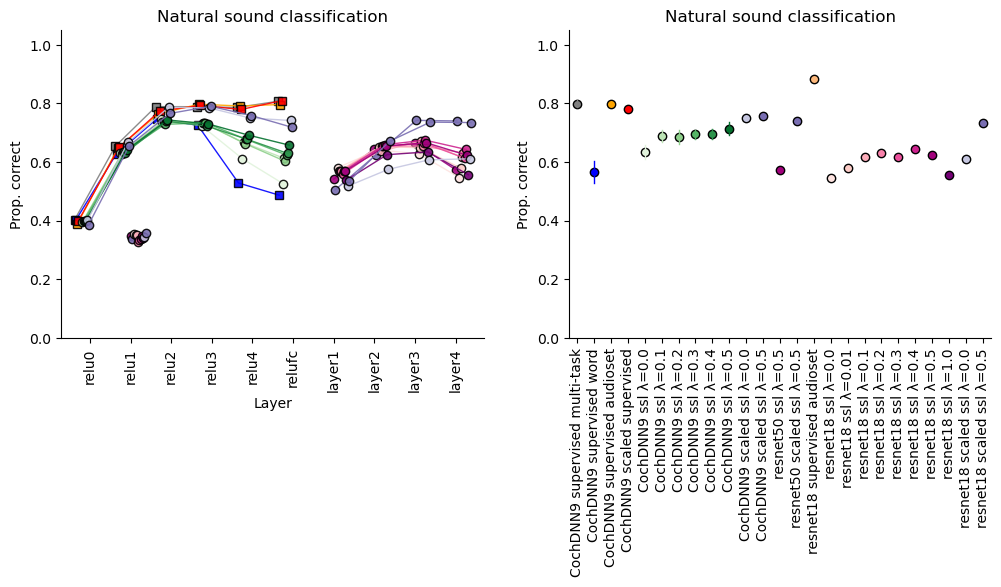

In [102]:
hue_order = [
    # Supervised
    'CochCNN9 supervised multi-task',
    'CochCNN9 supervised word',
    'CochCNN9 supervised audioset',
    'CochCNN9 scaled supervised',
    # SSL / Equivariant
    'CochCNN9 ssl λ=0.0',
    'CochCNN9 ssl λ=0.1',
    'CochCNN9 ssl λ=0.2',
    'CochCNN9 ssl λ=0.3',
    'CochCNN9 ssl λ=0.4',
    'CochCNN9 ssl λ=0.5',
    'CochCNN9 scaled ssl λ=0.0',
    'CochCNN9 scaled ssl λ=0.5',
    # # SSL / Dual
    # 'CochCNN9 ssl dual λ=0.0',
    # 'CochCNN9 ssl dual λ=0.0 unpaired augs',
    # 'CochCNN9 ssl dual λ=0.01',
    # 'CochCNN9 ssl dual λ=0.1',
    # 'CochCNN9 ssl dual λ=0.5',
    # Resnets 50
    'resnet50 ssl λ=0.5',
    'resnet50 scaled ssl λ=0.5',
    # Resnet 18
    'resnet18 supervised audioset',

    'resnet18 ssl λ=0.0',
    'resnet18 ssl λ=0.01',
    'resnet18 ssl λ=0.1',
    'resnet18 ssl λ=0.2',
    'resnet18 ssl λ=0.3',
    'resnet18 ssl λ=0.4',
    'resnet18 ssl λ=0.5',
    'resnet18 ssl λ=1.0',
    'resnet18 scaled ssl λ=0.0',
    'resnet18 scaled ssl λ=0.5',
]

hue_order = normalize_model_list(hue_order)
marker_palette = marker_palette_for_hue(hue_order)

# set palette via shared utils
base_colors = {
    'CochCNN9 supervised word': 'blue',
    'CochCNN9 supervised audioset': 'orange',
    'CochCNN9 scaled supervised': 'red',
    'CochCNN9 supervised multi-task': 'grey',
}
base_colors = normalize_palette_dict(base_colors)

hue_dict = build_model_palette(hue_order, base_colors)

# esc_50_to_plot = df[(df.arch_class == 'CochCNN9') & (~df.overall_acc.isna()) & (df.test_layer.str.contains('relu'))]
esc_50_to_plot = df[(~df.overall_acc.isna()) & (df.test_layer.str.contains('relu|layer'))]
# set layer order 


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

g = sns.pointplot(
    data=esc_50_to_plot,
    # order=layer_order,
    hue='model_name', y='overall_acc',  # col='arch_class',
    x="test_layer",
    palette=hue_dict,
    hue_order=hue_order,
    alpha=0.9,
    dodge=0.75,
    ax=axes[0],
    legend=False,
    markers=marker_palette,
    # ls='',
    mec='k',
    mew=1,
    lw=1, ms=6
    #  height=4, 
)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90)
xmin, xmax = axes[0].get_xlim()
axes[0].set_xlim(xmin - 0.2, xmax + 0.2)

g.set(ylim=(0, 1.05), title="Natural sound classification", ylabel='Prop. correct', xlabel='Layer')

test_layers = ['relu4', "layer4", 'final', 'avgpool']

esc_50_to_plot = df[(~df.overall_acc.isna()) & (df.test_layer.str.contains('relu|layer|avgpool'))]
to_plot = esc_50_to_plot[(esc_50_to_plot.model_name.isin(hue_order)) & esc_50_to_plot.test_layer.isin(test_layers)]
# to_plot = to_plot[~((to_plot.model_name.str.contains('kell')) & to_plot.test_layer.str.contains('avgpool'))]
# models_for_esc = ['CochCNN9 supervised word', 'CochCNN9 supervised multi-task', 'byol-a ']
# esc_50_to_plot = esc_50_to_plot[esc_50_to_plot.model_name.str.contains('CochCNN9|byola')]

g = sns.pointplot(
    data=to_plot,
    order=hue_order,
    x='model_name',
    y='overall_acc',
    # col='arch_class',
    hue="model_name",
    palette=hue_dict,
    # markers=marker_palette,
    # hue_order=hue_order,
    # height=4,
    ax=axes[1],
    mec='k',
    mew=1,
    lw=1, ms=6
)

g.set_xticklabels(labels=hue_order, rotation=90)  # ha='right', rotation_mode='anchor'
g.set(ylim=(0., 1.05), title="Natural sound classification", ylabel='Prop. correct', xlabel='')

sns.despine()


/tmp/ipykernel_1035179/2136436927.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  esc_50_to_plot['test_layer'] = pd.Categorical(esc_50_to_plot['test_layer'], categories=['relu1',  "layer1",  "layer2", "layer3",  "layer4", 'avgpool'], ordered=True)
/tmp/ipykernel_1035179/2136436927.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90)
/tmp/ipykernel_1035179/2136436927.py:81: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(labels=hue_order, rotation=90)


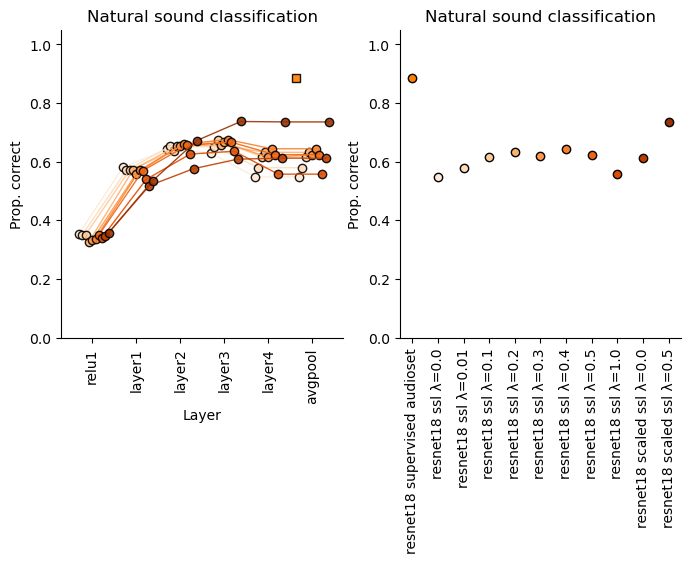

In [ ]:
hue_order = [
    # Supervised
    'resnet18 supervised audioset',
    'resnet18 supervised word',
    'resnet18 supervised multi-task',
    # SSL / Resnet18
    'resnet18 ssl λ=0.0',
    'resnet18 ssl λ=0.01',
    'resnet18 ssl λ=0.1',
    'resnet18 ssl λ=0.2',
    'resnet18 ssl λ=0.3',
    'resnet18 ssl λ=0.4',
    'resnet18 ssl λ=0.5',
    'resnet18 ssl λ=1.0',
    # Scaled SSL / Resnet18
    'resnet18 scaled ssl λ=0.0',
    'resnet18 scaled ssl λ=0.5',
]

hue_order = normalize_model_list(hue_order)
marker_palette = marker_palette_for_hue(hue_order)

# Separate supervised and SSL models
supervised_models = [hue_order[0]]  # resnet18 supervised audioset
ssl_models = hue_order[1:]  # All SSL models

# Use a different orange for supervised model (darker/more saturated orange)
supervised_palette = [(1.0, 0.5, 0.0)]  # Orange color
# Use oranges palette for resnet18 SSL models
ssl_palette = sns.color_palette("Oranges", n_colors=len(ssl_models))

# Combine palettes
hue_dict = dict(zip(supervised_models, supervised_palette))
hue_dict.update(dict(zip(ssl_models, ssl_palette)))
hue_dict = normalize_palette_dict(hue_dict)
hue_dict
# Filter for resnet18 models
esc_50_to_plot = df[(~df.overall_acc.isna()) & (df.test_layer.str.contains('relu|layer|avgpool')) & (df.model_name.str.contains('resnet18'))]
# put order so avgpool is last
esc_50_to_plot['test_layer'] = pd.Categorical(esc_50_to_plot['test_layer'], categories=['relu1',  "layer1",  "layer2", "layer3",  "layer4", 'avgpool'], ordered=True)
esc_50_to_plot = esc_50_to_plot.sort_values('test_layer')

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

g = sns.pointplot(
    data=esc_50_to_plot,
    hue='model_name', y='overall_acc',
    x="test_layer",
    palette=hue_dict,
    hue_order=hue_order,
    alpha=0.9,
    dodge=0.75,
    ax=axes[0],
    legend=False,
    markers=marker_palette,
    mec='k',
    mew=1,
    lw=1, ms=6
)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90)
xmin, xmax = axes[0].get_xlim()
axes[0].set_xlim(xmin - 0.2, xmax + 0.2)

g.set(ylim=(0, 1.05), title="Natural sound classification", ylabel='Prop. correct', xlabel='Layer')

test_layers = ['relu4', "layer4", 'final', 'avgpool']

to_plot = esc_50_to_plot[(esc_50_to_plot.model_name.isin(hue_order)) & esc_50_to_plot.test_layer.isin(test_layers)]

g = sns.pointplot(
    data=to_plot,
    order=hue_order,
    x='model_name',
    y='overall_acc',
    hue="model_name",
    palette=hue_dict,
    ax=axes[1],
    mec='k',
    mew=1,
    lw=1, ms=6
)

g.set_xticklabels(labels=hue_order, rotation=90)
g.set(ylim=(0., 1.05), title="Natural sound classification", ylabel='Prop. correct', xlabel='')

sns.despine()

/tmp/ipykernel_1035179/3546753681.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels(labels=model_names_for_x, rotation=90)
/tmp/ipykernel_1035179/3546753681.py:104: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(labels=model_names_for_x, rotation=90)


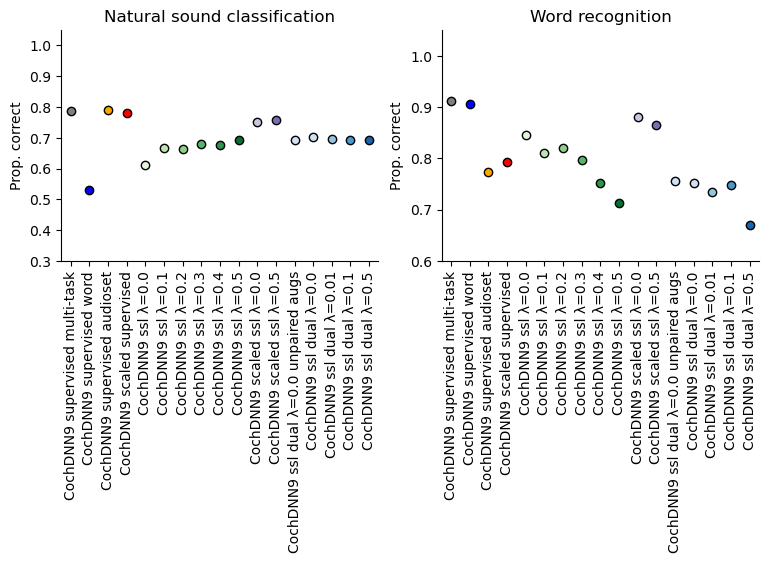

In [37]:
# ============================================================================
# Configuration
# ============================================================================

# Model selection
hue_order = [
    # Supervised
    'kell2018 supervised multi-task',
    'kell2018 supervised word',
    'kell2018 supervised jsin audioset',
    'kell2018 supervised unbalanced audioset',

    # SSL / Invariant
    'kell2018 ssl word',

    # SSL / Equivariant
    'kell2018 ssl λ=0.1',
    'kell2018 ssl λ=0.2',
    'kell2018 ssl λ=0.3',
    'kell2018 ssl λ=0.4',
    'kell2018 ssl λ=0.5',
    'kell2018 ssl unbalanced audioset λ=0.0',  
    'kell2018 ssl unbalanced audioset λ=0.5',  
    # 'kell2018 ssl jsin audioset',

    # SSL / Dual
    'kell2018 ssl dual λ=0.0 unpaired augs',
    'kell2018 ssl dual λ=0.0',
    'kell2018 ssl dual λ=0.01',
    'kell2018 ssl dual λ=0.1',
    'kell2018 ssl dual λ=0.5',
]

hue_order = normalize_model_list(hue_order)
hue_dict = normalize_palette_dict(hue_dict)

# Layer selection
test_layers = ['relu4', 'final', 'features']


# ============================================================================
# Data Preparation
# ============================================================================

# Filter dataframe
to_plot = df[df.model_name.str.contains('CochCNN9|byol')].copy()
to_plot = to_plot[(to_plot.model_name.isin(hue_order)) & 
                  (to_plot.test_layer.isin(test_layers))]

word_to_plot = to_plot # .drop_duplicates('model_name')

# Format x-axis labels
model_names_for_x = hue_order

# ============================================================================
# Plotting
# ============================================================================

fig, axs = plt.subplots(1, 2,
                         figsize=(9, 3),
                        #  gridspec_kw={'wspace': 0.5}
                    )

# Plot 1: Natural sound classification
sns.pointplot(
    data=to_plot,
    x='model_name',
    y='overall_acc',
    order=hue_order,
    hue='model_name',
    palette=hue_dict,
    ax=axs[0],
    mec='k',
    mew=1,
    lw=1,
    ms=6,
    legend=False
)

axs[0].set_xticklabels(labels=model_names_for_x, rotation=90)
axs[0].set(
    ylim=(0.3, 1.05),
    title="Natural sound classification",
    ylabel='Prop. correct',
    xlabel=''
)

# Plot 2: Word recognition
sns.pointplot(
    data=word_to_plot,
    x='model_name',
    y='word_top1_mean',
    order=hue_order,
    hue='model_name',
    palette=hue_dict,
    ax=axs[1],
    mec='k',
    mew=1,
    lw=1,
    ms=6,
    legend=False
)

axs[1].set_xticklabels(labels=model_names_for_x, rotation=90)
axs[1].set(
    ylim=(0.6, 1.05),
    title="Word recognition",
    ylabel='Prop. correct',
    xlabel=''
)

# Final adjustments
sns.despine()


# plt.savefig(outfig_dir/'sup_v_invariant_models.png', 
#             transparent=True, dpi=500, bbox_inches='tight')

/tmp/ipykernel_1035179/4088285187.py:100: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels(labels=model_names_for_x, rotation=90)
/tmp/ipykernel_1035179/4088285187.py:124: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(labels=model_names_for_x, rotation=90)


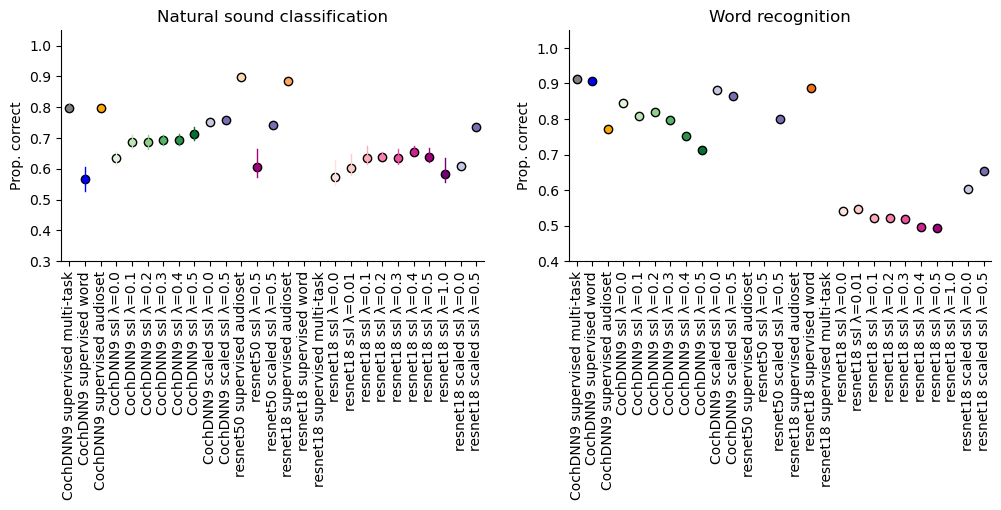

In [92]:
# ============================================================================
# Configuration
# ============================================================================

# Model selection
hue_order = [
    # Supervised
    'kell2018 supervised multi-task',
    'kell2018 supervised word',
    'kell2018 supervised audioset',

    # SSL / Invariant
    'kell2018 ssl word',

    # SSL / Equivariant
    'kell2018 ssl λ=0.1',
    'kell2018 ssl λ=0.2',
    'kell2018 ssl λ=0.3',
    'kell2018 ssl λ=0.4',
    'kell2018 ssl λ=0.5',
    'kell2018 scaled ssl λ=0.0',  
    'kell2018 scaled ssl λ=0.5',  
    # 'kell2018 ssl jsin audioset',

    # SSL / Dual
    # 'kell2018 ssl dual λ=0.0 unpaired augs',
    # 'kell2018 ssl dual λ=0.0',
    # 'kell2018 ssl dual λ=0.01',
    # 'kell2018 ssl dual λ=0.1',
    # 'kell2018 ssl dual λ=0.5',

    # Resnets 50 
    'resnet50 supervised audioset',
    'resnet50 ssl λ=0.5',
    'resnet50 scaled ssl λ=0.5',
    # Resnet 18
    'resnet18 supervised audioset',
    'resnet18 supervised word',
    'resnet18 supervised multi-task',
    'resnet18 ssl λ=0.0',
    'resnet18 ssl λ=0.01',
    'resnet18 ssl λ=0.1',
    'resnet18 ssl λ=0.2',
    'resnet18 ssl λ=0.3',
    'resnet18 ssl λ=0.4',
    'resnet18 ssl λ=0.5',
    'resnet18 ssl λ=1.0',
    'resnet18 scaled ssl λ=0.0',
    'resnet18 scaled ssl λ=0.5',
]

hue_order = normalize_model_list(hue_order)

marker_palette = marker_palette_for_hue(hue_order)
base_colors = get_standard_base_colors()
hue_dict = build_model_palette(hue_order, base_colors)
# Layer selection - include layers for both kell2018 (relu4, final, features) and resnets (layer4, avgpool)
test_layers = ['relu4', 'layer3', 'layer4', 'final', 'features', 'avgpool']


# ============================================================================
# Data Preparation
# ============================================================================

# Filter dataframe
# to_plot = df[df.model_name.str.contains('CochCNN9|byol')].copy()
to_plot = df[(df.model_name.isin(hue_order)) & 
                  (df.test_layer.isin(test_layers))]

word_to_plot = to_plot # .drop_duplicates('model_name')

# Format x-axis labels
model_names_for_x = hue_order

# ============================================================================
# Plotting
# ============================================================================

fig, axs = plt.subplots(1, 2,
                         figsize=(12, 3),
                        #  gridspec_kw={'wspace': 0.5}
                    )

# Plot 1: Natural sound classification
sns.pointplot(
    data=to_plot,
    x='model_name',
    y='overall_acc',
    order=hue_order,
    hue='model_name',
    palette=hue_dict,
    ax=axs[0],
    mec='k',
    mew=1,
    lw=1,
    ms=6,
    legend=False
)

axs[0].set_xticklabels(labels=model_names_for_x, rotation=90)
axs[0].set(
    ylim=(0.3, 1.05),
    title="Natural sound classification",
    ylabel='Prop. correct',
    xlabel=''
)

# Plot 2: Word recognition
sns.pointplot(
    data=word_to_plot,
    x='model_name',
    y='word_top1_mean',
    order=hue_order,
    hue='model_name',
    palette=hue_dict,
    ax=axs[1],
    mec='k',
    mew=1,
    lw=1,
    ms=6,
    legend=False
)

axs[1].set_xticklabels(labels=model_names_for_x, rotation=90)
axs[1].set(
    ylim=(0.4, 1.05),
    title="Word recognition",
    ylabel='Prop. correct',
    xlabel=''
)

# Final adjustments
sns.despine()


# plt.savefig(outfig_dir/'sup_v_invariant_models.png', 
#             transparent=True, dpi=500, bbox_inches='tight')

In [ ]:
to_plot = df[df.model_name.str.contains('CochCNN9|byol')].copy()
to_plot


,model_name,arch_class,test_layer,eq_lmbda,word_top1_mean,word_top1_sem,speaker_top1_mean,speaker_top1_sem,word_top5_mean,word_top5_sem,speaker_top5_mean,speaker_top5_sem,task,overall_acc
0,kell2018 ssl dual λ=0.0 unpaired augs,kell2018,kell2018,0.0,0.756403,0.001014,0.999490,0.000049,0.989996,0.000270,1.000000,2.942227e-10,800-word classification,NaN
1,kell2018 ssl dual λ=0.01,kell2018,kell2018,0.01,0.734701,0.001058,0.999429,0.000051,0.988358,0.000291,1.000000,2.942227e-10,800-word classification,NaN
2,kell2018 supervised word,kell2018,word,,0.726751,0.001035,0.998746,0.000078,0.972820,0.000693,0.999921,1.837652e-05,800-word classification,NaN
3,kell2018 ssl eq λ=0.1,kell2018,kell2018,0.1,0.612794,0.001162,0.998705,0.000078,0.959728,0.000822,0.999882,2.401590e-05,800-word classification,NaN
4,kell2018 ssl eq λ=0.1,kell2018,kell2018,0.1,0.809655,0.000949,0.998945,0.000069,0.994027,0.000184,1.000000,2.942227e-10,800-word classification,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
522,kell2018 ssl eq λ=0.8,kell2018,dropout,0.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.6240
523,kell2018 supervised multi-task,kell2018,dropout,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.8075
524,kell2018 ssl eq λ=0.1,kell2018,dropout,0.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.6130
525,kell2018 supervised word,kell2018,dropout,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.4875


/tmp/ipykernel_1816473/486397959.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(labels=model_names_for_x, rotation=90, ) #ha='right', rotation_mode='anchor')
/tmp/ipykernel_1816473/486397959.py:120: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(labels=model_names_for_x, rotation=90, ) #ha='right', rotation_mode='anchor')


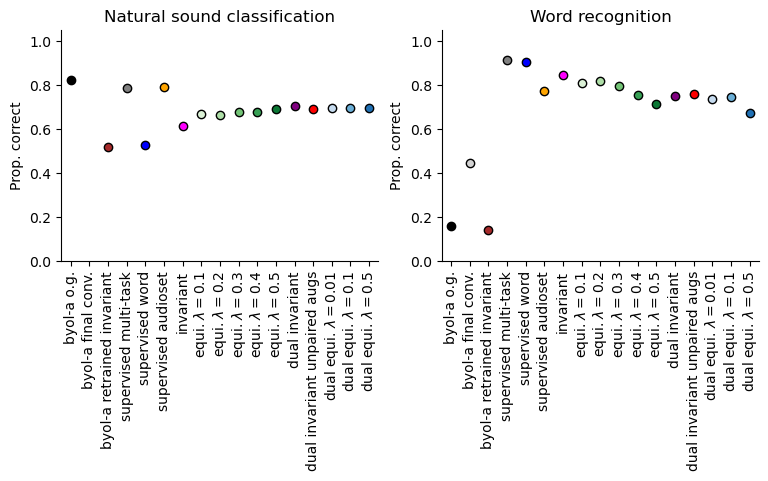

In [ ]:
hue_order = [ 
              'byol-a o.g.', 
              'byol-a final conv.', 
              'byol-a retrained invariant',
              'kell2018 supervised multi-task',
              'kell2018 supervised word',
              'kell2018 supervised audioset',
              'kell2018 invariant',
              'kell2018 equivariant 1e-01',
              'kell2018 equivariant 2e-01',
              'kell2018 equivariant 3e-01',
              'kell2018 equivariant 4e-01',
              'kell2018 equivariant 5e-01',
              'kell2018 dual invariant',
              "kell2018 dual invariant unpaired augs",
              'kell2018 dual equivariant 1e-02',
              'kell2018 dual equivariant 1e-01',
              'kell2018 dual equivariant 5e-01',
            #   'kell2018 equivariant 8e-01',
              ]

hue_order = normalize_model_list(hue_order)
marker_palette = marker_palette_for_hue(hue_order)
             
              

# set palette 
hue_dict = {}
hue_dict['byol-a o.g.'] = 'black'
hue_dict['byol-a final conv.'] = 'lightgrey'
hue_dict['byol-a retrained invariant'] = 'brown'
hue_dict['kell2018 supervised word'] = 'blue'
hue_dict['kell2018 supervised audioset'] = 'orange' 
hue_dict['kell2018 supervised multi-task'] = 'grey'
hue_dict['kell2018 invariant'] = 'magenta'
hue_dict['kell2018 dual invariant'] = 'purple'
hue_dict['kell2018 dual invariant unpaired augs'] = 'red'

# hue_dict['kell2018 dual equivariant 5e-01'] = 'olive'

hue_dict = normalize_palette_dict(hue_dict)

model_names_for_x = []

for name in hue_order:
    name = name.replace('CochCNN9 ', '')
    if "e-0" in name:
        lmbda = name.split(' ')[-1]
        if 'dual' in name:
            name = f"dual equi. $\\lambda=${float(lmbda)}"
        else:
            name = f"equi. $\\lambda=${float(lmbda)}"

    model_names_for_x.append(name)



layer_order = [
            'relu0', 'relu1', 'relu2', 'relu3', 'relu4', 'relufc'
]

eq_model_list = hue_order[7:12]
equi_palette = sns.color_palette("Greens", n_colors=len(eq_model_list)) 
equi_color_dict = dict(zip(eq_model_list, equi_palette))

dual_equi_model_list = hue_order[-3:]
dual_equi_palette = sns.color_palette("Blues", n_colors=len(dual_equi_model_list)) 
dual_equi_color_dict = dict(zip(dual_equi_model_list, dual_equi_palette))

hue_dict = {**hue_dict, **equi_color_dict, **dual_equi_color_dict}

fig, axs = plt.subplots(1,2, figsize=(9,3))

to_plot  = df[df.model_name.str.contains('CochCNN9|byol')].copy()

test_layers = ['relu4', 'final', 'features']

to_plot = to_plot[(to_plot.model_name.isin(hue_order)) & to_plot.test_layer.isin(test_layers)]
# to_plot = to_plot[~((to_plot.model_name.str.contains('kell')) & to_plot.test_layer.str.contains('avgpool'))]
# models_for_esc = ['kell2018 supervised word', 'kell2018 supervised multi-task', 'byol-a ']
# esc_50_to_plot = esc_50_to_plot[esc_50_to_plot.model_name.str.contains('kell2018|byola')]
g = sns.pointplot(data=to_plot,
                order=hue_order,
                x='model_name',
                y='overall_acc',
                # col='arch_class',
                hue="model_name",
                palette=hue_dict,

                # hue_order=hue_order,
                # height=4,
                ax = axs[0],
                mec='k',
                mew=1,
                lw=1, ms=6
                )

g.set_xticklabels(labels=model_names_for_x, rotation=90, ) #ha='right', rotation_mode='anchor')
g.set(ylim=(0., 1.05), title="Natural sound classification", ylabel='Prop. correct', xlabel='')
sns.despine()


# word_to_plot = to_plot[(~to_plot.word_top1_mean.isna())].dropna(axis=1).copy().reset_index(drop=True)

word_to_plot = to_plot.drop_duplicates('model_name')

g = sns.pointplot(data=word_to_plot,
                order=hue_order,
                x='model_name',
                y='word_top1_mean',
                # col='arch_class',
                hue="model_name",
                palette=hue_dict,

                # hue_order=hue_order,
                # height=4,
                ax = axs[1],
                mec='k',
                mew=1,
                lw=1, ms=6
                )

g.set_xticklabels(labels=model_names_for_x, rotation=90, ) #ha='right', rotation_mode='anchor')
g.set(ylim=(0, 1.05), title="Word recognition", ylabel='Prop. correct', xlabel='')
sns.despine()

# plt.subplots_adjust(wspace=0.5)

# speaker_to_plot = to_plot[(~to_plot.speaker_top1_mean.isna())].dropna(axis=1).copy().reset_index(drop=True)
# speaker_to_plot = speaker_to_plot.sort_values('speaker_top1_mean', ascending=False).drop_duplicates('model_name')

# g = sns.pointplot(data=to_plot,
#                 order=hue_order,
#                 hue="model_name",
#                 palette=hue_dict,
#                 y='speaker_top1_mean', 
#                 x="model_name", 
#                 ax=axs[2],
#                 # ls='',
#                 # markers=marker_palette,
#                 mec='k',
#                 mew=1,
#                 lw=1, ms=6
#                 )
# # g.set_xticklabels(labels=model_names_for_x, rotation=90)
# g.set(ylim=(0, 1.05), title="Speaker recognition", ylabel='Prop. correct', xlabel='')
# g.set_xticklabels(labels=model_names_for_x, rotation=90,)# ) #ha='right', rotation_mode='anchor')

# # handles, labels = g.get_legend_handles_labels()
# labels = [label.replace('CochCNN9 ', '') for label in labels]
# Create a new legend with customized labels and title
# g.legend(handles, labels, frameon=False, fontsize=8)

sns.despine()


# plt.savefig(outfig_dir/'all_models_speech_esc_relu4.png', transparent=True,dpi=500,  bbox_inches='tight')

